# TP04 - CLASIFICANDO POBRES EN LA EPH: MÉTODOS DE REGULARIZACIÓN Y CART – [Taller de Programación]
## Alumnos:  Kostzer Federico - Meza Palma Manuel Humberto - Pardini Maximiliano Gabriel - 
## Fecha: 28/11/2025


El objetivo de este trabajo es evaluar la predicción de pobres utilizando técnicas de regularización y de árboles. Van a utilizar las mismas bases X_train, y_train, X_test, y_test para cada año que crearon en el TP3.
Usen las mismas variables que usaron en el TP3 para predecir. Si piensan que hay más variables que son relevantes para predecir la pobreza las pueden incluir. Aclaración: Por simplicidad, usen únicamente la base de 2025. 

In [1]:
# %% ------------------------------------
# 📦 Configuración inicial
# %% ------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
import seaborn as sns
import numpy as np
from pathlib import Path
import os
print(os.getcwd())
import statsmodels.api as sm  
from sklearn import datasets
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, recall_score 
from sklearn.metrics import RocCurveDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score, auc
from sklearn.metrics import accuracy_score, recall_score, precision_score


# librerias de métricas de performance
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, recall_score 
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
sns.set(style="whitegrid")

C:\Users\Machi Pardini\Documents\GitHub\Big-Data-UBA--Grupo-3\TP04


In [2]:
# ======================================================
# TP4 – CARGA DE BASES + MODELADO 2025
# ======================================================

# ======================================================
# 1️⃣ DETECTAR RAÍZ DEL PROYECTO
# ======================================================

RUTA_REPO = Path.cwd()
while not (RUTA_REPO / ".git").exists() and RUTA_REPO != RUTA_REPO.parent:
    RUTA_REPO = RUTA_REPO.parent

RUTA_BASE = RUTA_REPO / "TP03"

print(f"📁 Raíz del repo: {RUTA_REPO}")
print(f"📂 Carpeta de bases: {RUTA_BASE}")


# ======================================================
# 2️⃣ CARGAR BASES
# ======================================================

respondieron = pd.read_csv(RUTA_BASE / "respondieron.csv", low_memory=False)
norespondieron = pd.read_csv(RUTA_BASE / "norespondieron.csv", low_memory=False)

respondieron.columns = respondieron.columns.str.strip()
norespondieron.columns = norespondieron.columns.str.strip()

print("Bases cargadas:")
print("respondieron:", respondieron.shape)
print("norespondieron:", norespondieron.shape)


# ======================================================
# 3️⃣ LIMPIAR VARIABLE pp3e_tot ANTES DE SEPARAR POR AÑO
# ======================================================

q99 = respondieron["pp3e_tot"].quantile(0.99)

respondieron["pp3e_tot_clean"] = respondieron["pp3e_tot"].where(
    respondieron["pp3e_tot"] <= q99
)

norespondieron["pp3e_tot_clean"] = norespondieron["pp3e_tot"].where(
    norespondieron["pp3e_tot"] <= q99
)

print("pp3e_tot_clean creada correctamente para ambas bases.")

# ======================================================
# 4️⃣ SEPARAR POR AÑO
# ======================================================

respondieron_2025 = respondieron[respondieron["ano4"] == 2025].copy()
norespondieron_2025 = norespondieron[norespondieron["ano4"] == 2025].copy()

print("Registros 2025:")
print("respondieron:", len(respondieron_2025))
print("norespondieron:", len(norespondieron_2025))


# ======================================================
# 5️⃣ VARIABLES SELECCIONADAS DEL TP3
# ======================================================

vars_pred = [
    'ch04','ch06','ch07','pp3e_tot_clean',
    'nivel_ed','estado','ch03','ch09','ch10'
]

num_cols = ['ch06','ch07','pp3e_tot_clean','estado','ch09','ch10']
cat_cols = ['ch04','nivel_ed']


# ======================================================
# 6️⃣ PREPARAR BASE PARA ENTRENAMIENTO (respondieron 2025)
# ======================================================

df_train = respondieron_2025[vars_pred + ['pobre']].copy()

# Imputación
for col in num_cols:
    df_train[col] = df_train[col].fillna(df_train[col].median())

# Dummies
df_train = pd.get_dummies(df_train, columns=cat_cols, drop_first=True)

# Separación X / y
X_2025 = df_train.drop(columns='pobre')
y_2025 = df_train['pobre']

# Intercepto
X_2025 = X_2025.assign(intercepto=1)


# ======================================================
# 7️⃣ SPLIT TRAIN/TEST
# ======================================================

X_train_2025, X_test_2025, y_train_2025, y_test_2025 = train_test_split(
    X_2025, y_2025,
    test_size=0.3,
    random_state=444
)

print("Tamaños del modelo:")
print("X_train:", X_train_2025.shape)
print("X_test :", X_test_2025.shape)
print("y_train:", y_train_2025.shape)
print("y_test :", y_test_2025.shape)


# ======================================================
# 8️⃣ CREAR CARPETA DE SALIDA TP04
# ======================================================

CARPETA_SALIDA = RUTA_REPO / "TP04"
CARPETA_SALIDA.mkdir(exist_ok=True)


# ======================================================
# 9️⃣ GUARDAR ARCHIVOS – NOMBRES DEFINITIVOS
# ======================================================

df_train.to_csv(CARPETA_SALIDA / "df_train_2025_model_ready.csv", index=False)
X_train_2025.to_csv(CARPETA_SALIDA / "X_train_2025.csv", index=False)
X_test_2025.to_csv(CARPETA_SALIDA / "X_test_2025.csv", index=False)
y_train_2025.to_csv(CARPETA_SALIDA / "y_train_2025.csv", index=False)
y_test_2025.to_csv(CARPETA_SALIDA / "y_test_2025.csv", index=False)

print("✔ Archivos de entrenamiento guardados.")


# ======================================================
# 🔟 PREPARAR norespondieron_2025 PARA PREDICCIÓN
# ======================================================

df_pred = norespondieron_2025[vars_pred].copy()

# Imputación consistente
for col in num_cols:
    df_pred[col] = df_pred[col].fillna(df_train[col].median())

# Dummies
df_pred = pd.get_dummies(df_pred, columns=cat_cols, drop_first=True)

# Alinear columnas con modelo
df_pred = df_pred.reindex(columns=X_2025.columns, fill_value=0)

df_pred.to_csv(CARPETA_SALIDA / "df_predict_2025_model_ready.csv", index=False)

print("✔ Base lista para predicción guardada.")
print("Todo listo para continuar con el TP04.")


📁 Raíz del repo: C:\Users\Machi Pardini\Documents\GitHub\Big-Data-UBA--Grupo-3
📂 Carpeta de bases: C:\Users\Machi Pardini\Documents\GitHub\Big-Data-UBA--Grupo-3\TP03
Bases cargadas:
respondieron: (79964, 254)
norespondieron: (12491, 246)
pp3e_tot_clean creada correctamente para ambas bases.
Registros 2025:
respondieron: 33372
norespondieron: 12053
Tamaños del modelo:
X_train: (23360, 15)
X_test : (10012, 15)
y_train: (23360,)
y_test : (10012,)
✔ Archivos de entrenamiento guardados.
✔ Base lista para predicción guardada.
Todo listo para continuar con el TP04.


A.  Modelo de Regresion Logistica con Regularización: Ridge y LASSO

1. Visualización: Grafiquen en dos paneles distintos los coeficientes de la penalidad de LASSO y Ridge para la grilla del parámetros de penalidad λ=10^n con n∈{-5,-4,-3,…,4,5} e interpreten la regularización con cada penalidad. (Hint: en la función Logistic Regression la opción C es la inversa de la fuerza de penalidad, en lugar de alpha. Según el tamaño de su matriz, se recomienda probar con distintas opciones de solver para el uso eficiente computacional).

In [3]:
# ================================================
# 1️⃣ DETECTAR RAÍZ DEL PROYECTO
# ================================================

RUTA_REPO = Path.cwd()
while not (RUTA_REPO / ".git").exists() and RUTA_REPO != RUTA_REPO.parent:
    RUTA_REPO = RUTA_REPO.parent

RUTA_TP04 = RUTA_REPO / "TP04"

print(f"📁 Raíz del repo: {RUTA_REPO}")
print(f"📂 Carpeta TP04: {RUTA_TP04}")


# ================================================
# 2️⃣ CARGAR BASES DEL TP04
# ================================================
X_train = pd.read_csv(RUTA_TP04 / "X_train_2025.csv")
y_train = pd.read_csv(RUTA_TP04 / "y_train_2025.csv").values.ravel()

X_test  = pd.read_csv(RUTA_TP04 / "X_test_2025.csv")
y_test  = pd.read_csv(RUTA_TP04 / "y_test_2025.csv").values.ravel()

print("Bases cargadas correctamente:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


📁 Raíz del repo: C:\Users\Machi Pardini\Documents\GitHub\Big-Data-UBA--Grupo-3
📂 Carpeta TP04: C:\Users\Machi Pardini\Documents\GitHub\Big-Data-UBA--Grupo-3\TP04
Bases cargadas correctamente:
X_train: (23360, 15)
y_train: (23360,)
X_test : (10012, 15)
y_test : (10012,)


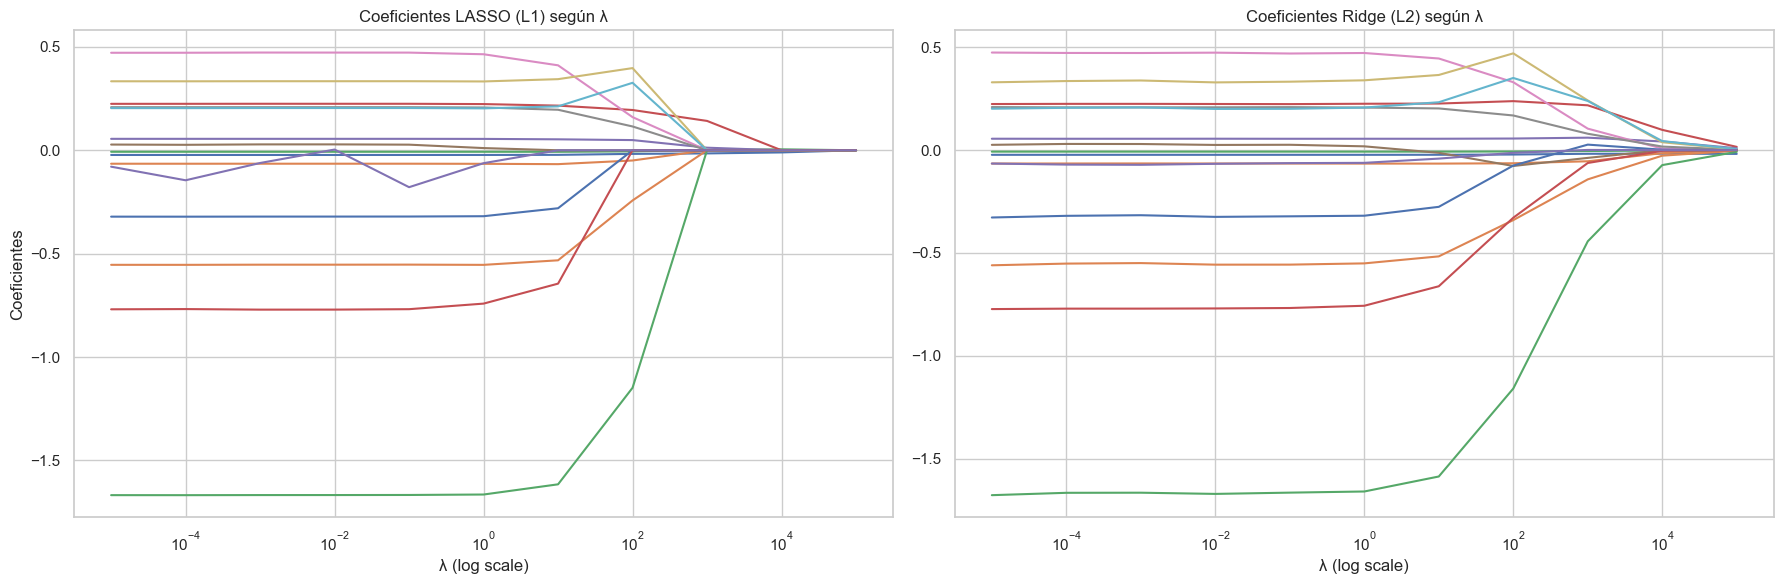

In [4]:
# ================================================
# 3️⃣ PUNTO A — LASSO y RIDGE: Coeficientes vs λ
# ================================================
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Grilla λ = 10^n , n ∈ {-5 ... 5}
lambdas = [10**n for n in range(-5, 6)]
Cs = [1/l for l in lambdas]  # C = 1/λ

# Para guardar coeficientes
coef_lasso = []
coef_ridge = []

feature_names = X_train.columns  # 15 columnas

for C in Cs:
    # ------- Modelo LASSO (L1) -------
    logit_l1 = LogisticRegression(
        penalty="l1",
        C=C,
        solver="liblinear",
        max_iter=2000
    )
    logit_l1.fit(X_train, y_train)
    coef_lasso.append(logit_l1.coef_[0])

    # ------- Modelo RIDGE (L2) -------
    logit_l2 = LogisticRegression(
        penalty="l2",
        C=C,
        solver="lbfgs",
        max_iter=2000
    )
    logit_l2.fit(X_train, y_train)
    coef_ridge.append(logit_l2.coef_[0])

# Convertir a DataFrame
coef_lasso = pd.DataFrame(coef_lasso, columns=feature_names, index=lambdas)
coef_ridge = pd.DataFrame(coef_ridge, columns=feature_names, index=lambdas)

# ================================================
# 4️⃣ Gráficos de coeficientes
# ================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Panel LASSO
axes[0].plot(coef_lasso.index, coef_lasso)
axes[0].set_xscale('log')
axes[0].set_title("Coeficientes LASSO (L1) según λ")
axes[0].set_xlabel("λ (log scale)")
axes[0].set_ylabel("Coeficientes")
axes[0].grid(True)

# Panel RIDGE
axes[1].plot(coef_ridge.index, coef_ridge)
axes[1].set_xscale('log')
axes[1].set_title("Coeficientes Ridge (L2) según λ")
axes[1].set_xlabel("λ (log scale)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ================================================
# 5️⃣ EXPORTAR EL GRÁFICO
# ================================================
fig.savefig("coeficientes_lasso_ridge.png", dpi=300, bbox_inches="tight")
fig.savefig("coeficientes_lasso_ridge.pdf", dpi=300, bbox_inches="tight")



2. Penalidad óptima por Cross-validation y visualización: Usando Logistic Regression CV dividiendo la base 5 partes (5-fold), elijan la penalidad óptima λ en la grilla mencionada arriba. ¿Qué λ^cv seleccionó en cada caso? Hagan un grafico de linea con puntos conectados mostrando la distribución del error de clasificaición promedio entre folds para cada λ. Opcional: para la regularización LASSO, generen otro plot de puntos conectados, para la proporción de variables ignoradas por el modelo en función de λ, es decir la proporción de variables para las cuales el coeficiente asociado es cero.

LASSO λ^cv óptima: 10.0


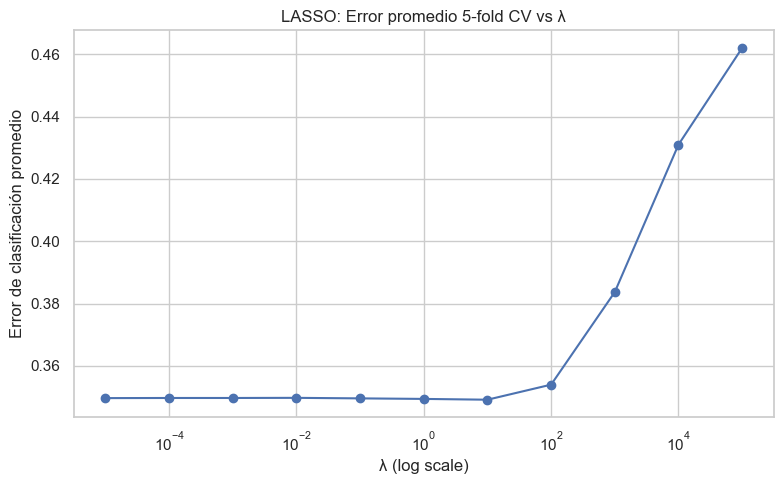

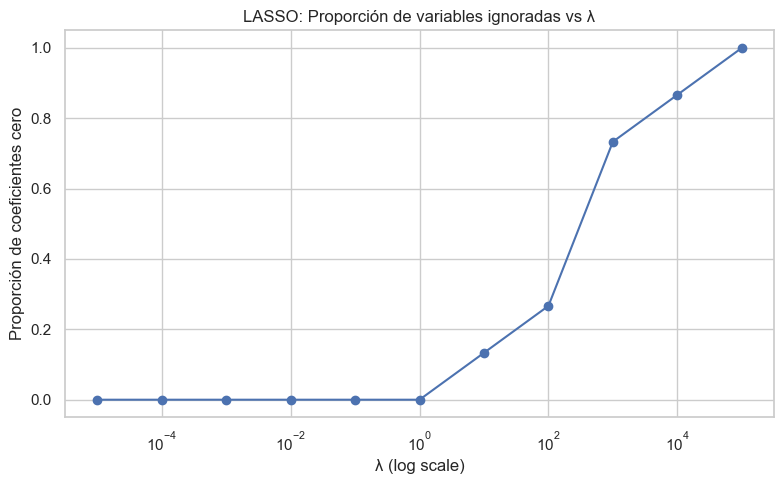

Ridge λ^cv óptima: 1.0


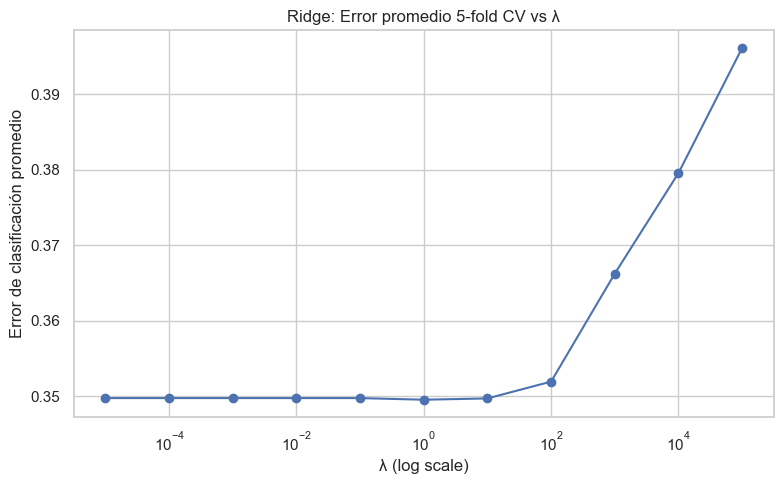

In [5]:
# ================================================
# PUNTO B — Penalidad óptima por Cross-Validation + gráficos 
# ================================================

# ----------------------
# LASSO (L1) con 5-fold CV
# ----------------------
logit_l1_cv = LogisticRegressionCV(
    Cs=Cs,
    cv=5,
    penalty="l1",
    solver="liblinear",
    scoring="accuracy",
    max_iter=2000,
    refit=True
)

logit_l1_cv.fit(X_train, y_train)

# Penalidad óptima
C_opt_l1 = logit_l1_cv.C_[0]
lambda_opt_l1 = 1 / C_opt_l1
print("LASSO λ^cv óptima:", lambda_opt_l1)

# Error promedio 5-fold por λ
mean_scores_l1 = logit_l1_cv.scores_[1].mean(axis=0)
error_l1 = 1 - mean_scores_l1

# Gráfico error vs λ
fig_l1, ax_l1 = plt.subplots(figsize=(8,5))
ax_l1.plot(lambdas, error_l1, marker='o', linestyle='-')
ax_l1.set_xscale('log')
ax_l1.set_xlabel("λ (log scale)")
ax_l1.set_ylabel("Error de clasificación promedio")
ax_l1.set_title("LASSO: Error promedio 5-fold CV vs λ")
ax_l1.grid(True)
plt.tight_layout()
plt.show()

# Exportar gráfico LASSO error
fig_l1.savefig(CARPETA_SALIDA / "lasso_error_cv.png", dpi=300, bbox_inches="tight")
fig_l1.savefig(CARPETA_SALIDA / "lasso_error_cv.pdf", dpi=300, bbox_inches="tight")


# ----------------------
# Proporción de coeficientes cero por λ (calculado "a mano")
# ----------------------
proporcion_cero = []
for C in Cs:
    model = LogisticRegression(
        penalty='l1',
        C=C,
        solver='liblinear',
        max_iter=2000
    )
    model.fit(X_train, y_train)
    proporcion_cero.append(np.mean(model.coef_[0] == 0))

fig_l1_zero, ax_l1_zero = plt.subplots(figsize=(8,5))
ax_l1_zero.plot(lambdas, proporcion_cero, marker='o', linestyle='-')
ax_l1_zero.set_xscale('log')
ax_l1_zero.set_xlabel("λ (log scale)")
ax_l1_zero.set_ylabel("Proporción de coeficientes cero")
ax_l1_zero.set_title("LASSO: Proporción de variables ignoradas vs λ")
ax_l1_zero.grid(True)
plt.tight_layout()
plt.show()

# Exportar gráfico LASSO proporción coef cero
fig_l1_zero.savefig(CARPETA_SALIDA / "lasso_proporcion_coef_cero.png", dpi=300, bbox_inches="tight")
fig_l1_zero.savefig(CARPETA_SALIDA / "lasso_proporcion_coef_cero.pdf", dpi=300, bbox_inches="tight")


# ----------------------
# RIDGE (L2) con 5-fold CV
# ----------------------
logit_l2_cv = LogisticRegressionCV(
    Cs=Cs,
    cv=5,
    penalty="l2",
    solver="lbfgs",
    scoring="accuracy",
    max_iter=2000,
    refit=True
)

logit_l2_cv.fit(X_train, y_train)

# Penalidad óptima
C_opt_l2 = logit_l2_cv.C_[0]
lambda_opt_l2 = 1 / C_opt_l2
print("Ridge λ^cv óptima:", lambda_opt_l2)

# Error promedio 5-fold por λ
mean_scores_l2 = logit_l2_cv.scores_[1].mean(axis=0)
error_l2 = 1 - mean_scores_l2

# Gráfico error vs λ
fig_l2, ax_l2 = plt.subplots(figsize=(8,5))
ax_l2.plot(lambdas, error_l2, marker='o', linestyle='-')
ax_l2.set_xscale('log')
ax_l2.set_xlabel("λ (log scale)")
ax_l2.set_ylabel("Error de clasificación promedio")
ax_l2.set_title("Ridge: Error promedio 5-fold CV vs λ")
ax_l2.grid(True)
plt.tight_layout()
plt.show()

# Exportar gráfico Ridge
fig_l2.savefig(CARPETA_SALIDA / "ridge_error_cv.png", dpi=300, bbox_inches="tight")
fig_l2.savefig(CARPETA_SALIDA / "ridge_error_cv.pdf", dpi=300, bbox_inches="tight")


3. Estimación con λ^cv y comparación de coeficientes: Estimen una Regresión Logística usando X_train de respondieron_2025 sin penalidad, con penalidad L1 y L2 siendo la penalidad óptima λ^cv elegida en el ítem anterior. Exporten una tabla con las siguientes columnas: (i) los coeficientes estimados para cada variable sin penalidad, (ii) coeficientes de penalidad L1, y (ii) coeficientes de penalidad L2.  Interpreten los resultados de la tabla y conteste: ¿cómo son los coeficientes de la regularización con respecto a logit sin penalidad? ¿La penalidad L2 elimina variables de las que incluyeron en su matriz X_train?

In [6]:
# ================================================
# 3️. Estimación con λ^CV y comparación de coeficientes
# ================================================

# Penalidad óptima obtenida en el punto B
lambda_opt = 10.0
C_opt = 1 / lambda_opt

# --------------------------------
# 1️⃣ Modelo sin penalidad
# --------------------------------
logit_none = LogisticRegression(
    penalty=None,      # Aquí se corrige 'none' -> None
    solver='lbfgs',
    max_iter=2000
)
logit_none.fit(X_train, y_train)

# --------------------------------
# 2️⃣ Modelo LASSO (L1) con λ^CV
# --------------------------------
logit_l1 = LogisticRegression(
    penalty='l1',
    C=C_opt,
    solver='liblinear',
    max_iter=2000
)
logit_l1.fit(X_train, y_train)

# --------------------------------
# 3️⃣ Modelo Ridge (L2) con λ^CV
# --------------------------------
logit_l2 = LogisticRegression(
    penalty='l2',
    C=C_opt,
    solver='lbfgs',
    max_iter=2000
)
logit_l2.fit(X_train, y_train)

# --------------------------------
# 4️⃣ Comparación de coeficientes
# --------------------------------
coef_table = pd.DataFrame({
    'Variable': X_train.columns,
    'Coef_sin_penalidad': logit_none.coef_[0],
    'Coef_L1': logit_l1.coef_[0],
    'Coef_L2': logit_l2.coef_[0]
})

# Exportar tabla
coef_table.to_csv(CARPETA_SALIDA / "coef_comparacion.csv", index=False)
print("✔ Tabla de coeficientes exportada")
coef_table


✔ Tabla de coeficientes exportada


,Variable,Coef_sin_penalidad,Coef_L1,Coef_L2
0,ch06,-0.022672,-0.022189,-0.022516
1,ch07,-0.065662,-0.067198,-0.065490
2,pp3e_tot_clean,-0.007312,-0.007493,-0.007227
3,estado,0.223608,0.216118,0.226528
4,ch03,0.055176,0.052871,0.055356
5,ch09,0.015168,0.000000,-0.013067
6,ch10,0.467638,0.412283,0.445610
7,ch04_2,0.207815,0.195763,0.202812
8,nivel_ed_2,0.325964,0.343418,0.365459
9,nivel_ed_3,0.197959,0.211781,0.232890


B. Árboles de Decisión

4.	Estimen un árbol de decisión podado (CART) eligiendo el hiperparámetro de costo de complejidad  del árbol (ccp_aplha) con 10-fold Cross-Validation. En un gráfico de línea, muestre el error de clasificación en función de la grilla de valores que uso para ccp_aplha. Comenten los resultados.

In [7]:
# ======================================================
# B1. SELECCIÓN DE ccp_alpha POR 10-FOLD CV 
# ======================================================

# Árbol base para obtener ruta de complejidad
arbol_base = DecisionTreeClassifier(
    random_state=444
)

path = arbol_base.cost_complexity_pruning_path(X_train_2025, y_train_2025)

ccp_alphas = path.ccp_alphas

# 1) Nos quedamos solo con alphas >= 0
ccp_alphas = ccp_alphas[ccp_alphas >= 0]

# 2) Sacamos el último (árbol con solo la raíz)
if len(ccp_alphas) > 1:
    ccp_alphas = ccp_alphas[:-1]

print("Cantidad total de alphas:", len(ccp_alphas))

# 3) Si hay demasiados, muestreamos algunos (p.ej. 40)
max_alphas = 40
if len(ccp_alphas) > max_alphas:
    idx = np.linspace(0, len(ccp_alphas) - 1, max_alphas, dtype=int)
    ccp_alphas = ccp_alphas[idx]

print("Alphas que vamos a evaluar con CV:", len(ccp_alphas))

errores_medios = []

# 10-fold CV estratificado
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=444)

for i, alpha in enumerate(ccp_alphas, start=1):
    arbol = DecisionTreeClassifier(
        random_state=444,
        ccp_alpha=float(alpha)
    )
    scores = cross_val_score(
        arbol,
        X_train_2025,
        y_train_2025,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1  # usa todos los núcleos disponibles
    )
    errores_medios.append(1 - scores.mean())
    print(f"{i}/{len(ccp_alphas)}  alpha={alpha:.6g}  error={1 - scores.mean():.4f}")

errores_medios = np.array(errores_medios)

alpha_optimo = ccp_alphas[np.argmin(errores_medios)]
print("\nccp_alpha óptimo según 10-fold CV:", alpha_optimo)


Cantidad total de alphas: 2712
Alphas que vamos a evaluar con CV: 40
1/40  alpha=0  error=0.3908
2/40  alpha=1.46631e-07  error=0.3908
3/40  alpha=1.62434e-06  error=0.3907
4/40  alpha=2.85388e-06  error=0.3900
5/40  alpha=4.28082e-06  error=0.3897
6/40  alpha=6.58588e-06  error=0.3886
7/40  alpha=7.34842e-06  error=0.3885
8/40  alpha=9.78474e-06  error=0.3874
9/40  alpha=1.14155e-05  error=0.3880
10/40  alpha=1.28425e-05  error=0.3869
11/40  alpha=1.42694e-05  error=0.3870
12/40  alpha=1.42694e-05  error=0.3870
13/40  alpha=1.42694e-05  error=0.3871
14/40  alpha=1.71233e-05  error=0.3854
15/40  alpha=1.90259e-05  error=0.3849
16/40  alpha=2.08333e-05  error=0.3840
17/40  alpha=2.20157e-05  error=0.3833
18/40  alpha=2.33499e-05  error=0.3825
19/40  alpha=2.53678e-05  error=0.3806
20/40  alpha=2.61606e-05  error=0.3803
21/40  alpha=2.8041e-05  error=0.3798
22/40  alpha=2.85388e-05  error=0.3792
23/40  alpha=3.05773e-05  error=0.3773
24/40  alpha=3.21062e-05  error=0.3748
25/40  alpha=3.

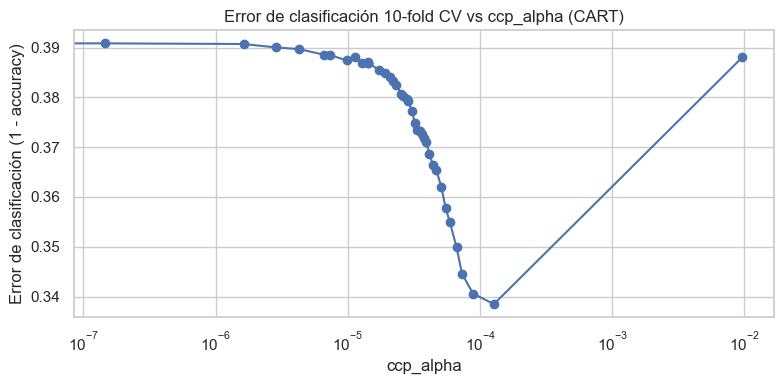

In [9]:
# ======================================================
# B2. GRÁFICO ERROR CV vs ccp_alpha
# ======================================================
plt.figure(figsize=(8, 4))
plt.plot(ccp_alphas, errores_medios, marker="o")
plt.xlabel("ccp_alpha")
plt.ylabel("Error de clasificación (1 - accuracy)")
plt.title("Error de clasificación 10-fold CV vs ccp_alpha (CART)")
plt.xscale("log")   # opcional, ayuda a ver mejor la escala
plt.grid(True)
plt.tight_layout()
plt.show()


In [8]:
# ======================================================
# B3. AJUSTAR ÁRBOL PODADO CON ccp_alpha ÓPTIMO
# ======================================================
arbol_podado = DecisionTreeClassifier(
    random_state=444,
    ccp_alpha=float(alpha_optimo)
)

arbol_podado.fit(X_train_2025, y_train_2025)

print("Profundidad del árbol podado:", arbol_podado.get_depth())
print("Cantidad de hojas:", arbol_podado.get_n_leaves())


Profundidad del árbol podado: 11
Cantidad de hojas: 113


5.	Visualización del árbol podado por cross-validation: En un panel A, muestren el gráfico del árbol que obtuvieron e interpreten. En un panel B, muestren en un gráfico la importancia de cada uno de los predictores. ¿Podría decirse que los coeficientes de las variables menos importantes son los que LASSO “achicó” a cero? 

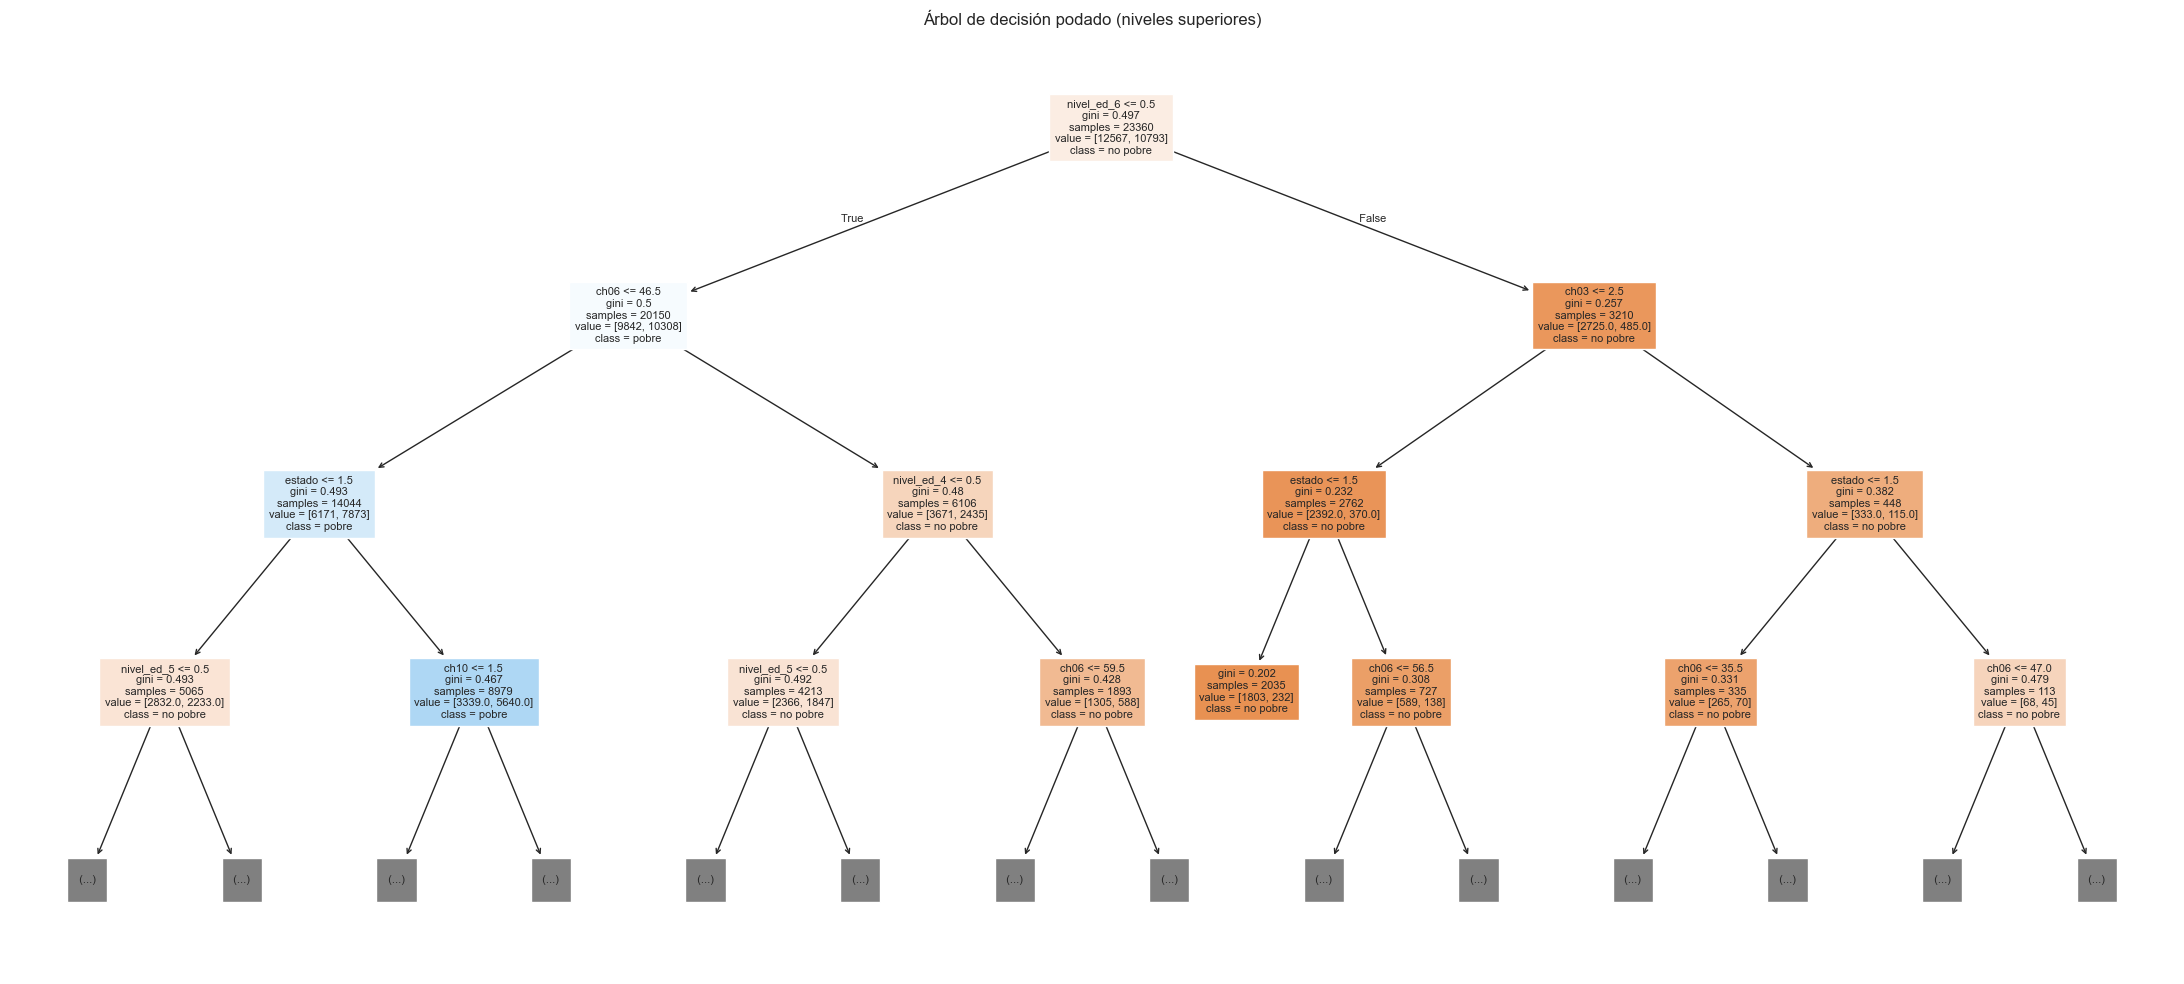

In [9]:
plt.figure(figsize=(22, 10))
plot_tree(
    arbol_podado,
    feature_names=X_train_2025.columns,
    class_names=["no pobre", "pobre"],
    filled=True,
    max_depth=3,   # <<< solo los niveles superiores
    fontsize=8
)
plt.title("Árbol de decisión podado (niveles superiores)")
plt.tight_layout()
plt.show()


nivel_ed_6        0.338306
ch06              0.194673
estado            0.136658
nivel_ed_5        0.076569
pp3e_tot_clean    0.064572
nivel_ed_4        0.054755
ch03              0.041215
ch07              0.030714
ch10              0.021396
ch04_2            0.017126
nivel_ed_3        0.011741
nivel_ed_2        0.008915
ch09              0.003359
nivel_ed_7        0.000000
intercepto        0.000000
dtype: float64

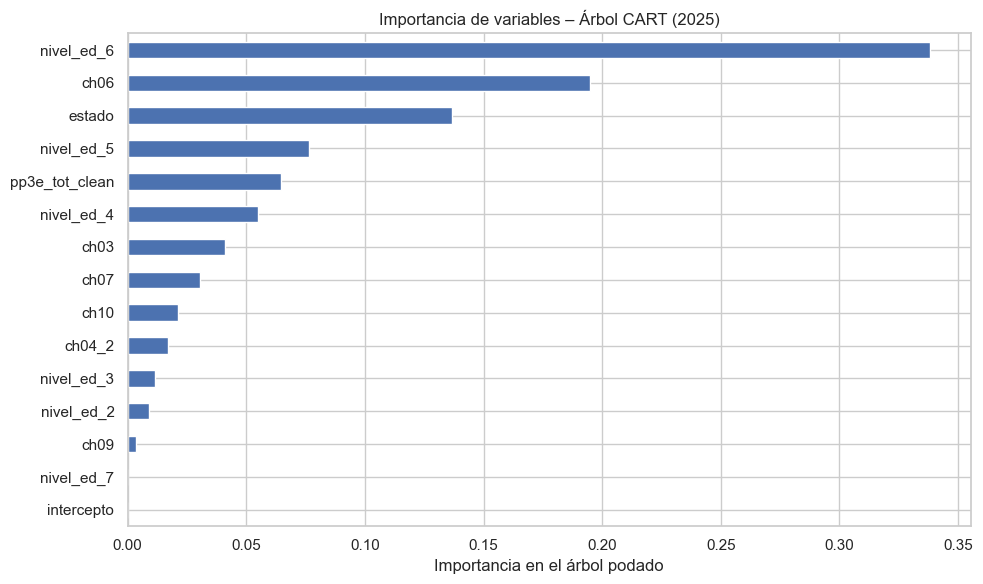

In [12]:
# ======================================================
# B4. IMPORTANCIA DE VARIABLES
# ======================================================

importancias = pd.Series(
    arbol_podado.feature_importances_,
    index=X_train_2025.columns
).sort_values(ascending=False)

# Mirar todas si querés
display(importancias)

# Gráfico de las 15 más importantes
plt.figure(figsize=(10, 6))
importancias.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Importancia en el árbol podado")
plt.title("Importancia de variables – Árbol CART (2025)")
plt.tight_layout()
plt.show()


 C. Comparación entre métodos

6.	Computen la matriz de confusión (p>0,5), la curva ROC y las dos métricas que utilizó en el TP3. Comparen el desempeño de Regresiones Logísticas sin penalidad, KNN con K-CV (ambos en TP3), logit con penalidad LASSO y Ridge, y el árbol de decisión podado. Comenten los resultados. ¿Qué pueden decir del trade-off entre comunicación de los resultados y performance predictiva? En este caso, ¿hay una ventaja por utilizar un método no lineal? Incorporen dentro de la justificación (1 - accuracy) para argumentar. 

In [10]:
# Preparacion de bases para entrenar KNN
# Veamos la dimension de los vectores creados
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

X_train

# Eliminamos la columna del intercepto de los conjuntos de predictores

X_train_knn = X_train.drop(columns=['intercepto'])
X_test_knn = X_test.drop(columns=['intercepto'])

(23360, 15) (10012, 15) (23360,) (10012,)


In [11]:
# Entrenamos modelo KNN con cv para elecccion de hiperparametros y k (1,10)

# 1. Definimos los valores de K a probar
k_values = range(1, 11)
cv_scores = []

# 2. Cross-validation con 5 pliegues
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_knn, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())


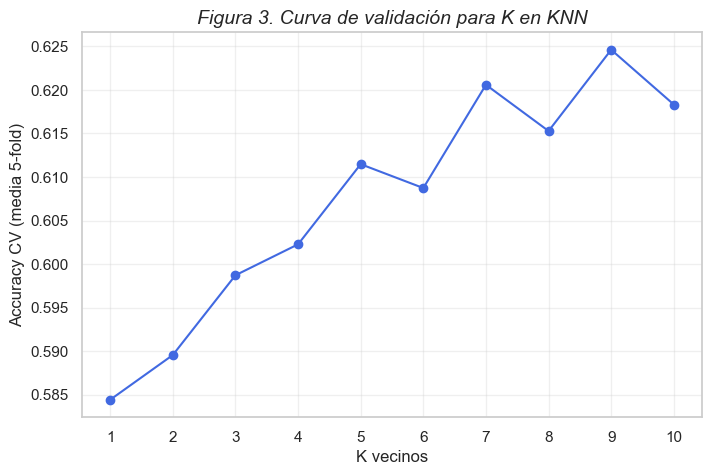

✅ K óptimo según 5-fold CV: 9 (accuracy promedio = 0.625)


In [12]:
#  Graficamos los resultados
plt.figure(figsize=(8,5))
plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='royalblue')
plt.title('Figura 3. Curva de validación para K en KNN', fontsize=14, style='italic', loc='center')
plt.xlabel('K vecinos')
plt.ylabel('Accuracy CV (media 5-fold)')
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

# Mostramos el K óptimo
k_optimo = k_values[np.argmax(cv_scores)]
accuracy_max = max(cv_scores)
print(f"✅ K óptimo según 5-fold CV: {k_optimo} (accuracy promedio = {accuracy_max:.3f})")

In [13]:
# ---------------------------
#  Probabilidades del KNN
# ---------------------------
# Entrenamos un KNN final con el K óptimo encontrado por CV
knn_final = KNeighborsClassifier(n_neighbors=k_optimo)
knn_final.fit(X_train_knn, y_train)

# Probabilidades de ser pobre en el test (columna de la clase 1)
yknn_new = knn_final.predict(X_test_knn)

In [14]:
# Modelos logit estimados con CV y penalidades optimas

ynone_new = logit_none.predict(X_test) ## Logit sin penalidad
yl1_new = logit_l1.predict(X_test) ## Lasso (L1)
yl2_new = logit_l2.predict(X_test) ## Ridge (L2)

print(ynone_new)

# Clasificador de Bayes none
ynone_new = np.where(ynone_new>0.5, 1, ynone_new)
ynone_new = np.where(ynone_new<=0.5, 0, ynone_new)
print(ynone_new)

# Clasificador de Bayes L1
yl1_new = np.where(yl1_new>0.5, 1, yl1_new)
yl1_new = np.where(yl1_new<=0.5, 0, yl1_new)
print(yl1_new)

# Clasificador de Bayes L2
yl2_new = np.where(yl2_new>0.5, 1, yl2_new)
yl2_new = np.where(yl2_new<=0.5, 0, yl2_new)
print(yl2_new)

# Clasificador de Bayes KNN cv
yknn_new = np.where(yknn_new>0.5, 1, yknn_new)
yknn_new = np.where(yknn_new<=0.5, 0, yknn_new)
print(yknn_new)

# Clasificador de Bayes arbol podado

ytree_new = arbol_podado.predict(X_test)

ytree_new = np.where(ytree_new>0.5, 1, ytree_new)
ytree_new = np.where(ytree_new<=0.5, 0, ytree_new)
print(ytree_new)


[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[0 0 0 ... 0 0 0]
[1 0 0 ... 1 1 0]
[0 0 0 ... 0 1 0]


In [ ]:
# Matrices de confusion
#Python pone en las filas las Y y en las columnas las Y hat (y predichas)
# Diccionario con los nombres de cada modelo y sus predicciones
# Cantidad de (vp+vn) sobre total
# Acá, la matriz de confusión tiene en las filas los valores ciertos y en las columnas los valores predicho
preds = {
    "Logit - None": ynone_new,
    "Logit - L1": yl1_new,
    "Logit - L2": yl2_new,
    "KNN": yknn_new,
    "Decision Tree": ytree_new
}

for nombre, y_pred in preds.items():
    print(f"\n==============================")
    print(f"🔷 Matriz de confusión - Modelo: {nombre}")
    print("==============================")

    conf_mat = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    print("Confusion Matrix:\n", conf_mat)
    print(f"Accuracy Score: {acc:.4f}")



🔷 Matriz de confusión - Modelo: Logit - None
Confusion Matrix:
 [[3768 1697]
 [1826 2721]]
Accuracy Score: 0.6481

🔷 Matriz de confusión - Modelo: Logit - L1
Confusion Matrix:
 [[3775 1690]
 [1825 2722]]
Accuracy Score: 0.6489

🔷 Matriz de confusión - Modelo: Logit - L2
Confusion Matrix:
 [[3765 1700]
 [1827 2720]]
Accuracy Score: 0.6477

🔷 Matriz de confusión - Modelo: KNN
Confusion Matrix:
 [[3555 1910]
 [1804 2743]]
Accuracy Score: 0.6290

🔷 Matriz de confusión - Modelo: Decision Tree
Confusion Matrix:
 [[3555 1910]
 [1470 3077]]
Accuracy Score: 0.6624


In [15]:
# Metricas de modelos

# Diccionario con los modelos y sus predicciones
preds = {
    "Logit - None": ynone_new,
    "Logit - L1": yl1_new,
    "Logit - L2": yl2_new,
    "KNN": yknn_new,
    "Decision Tree": ytree_new
}

# Lista para guardar los resultados
resultados = []

for nombre, y_pred in preds.items():
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)          # Sensibilidad (TPR)
    prec = precision_score(y_test, y_pred)      # Precisión

    resultados.append({
        "Modelo": nombre,
        "Accuracy": round(acc, 4),
        "Recall": round(rec, 4),
        "Precision": round(prec, 4)
    })

# Convertimos a DataFrame
tabla_metricas = pd.DataFrame(resultados)

print(tabla_metricas)


          Modelo  Accuracy  Recall  Precision
0   Logit - None    0.6481  0.5980     0.6160
1     Logit - L1    0.6489  0.5986     0.6170
2     Logit - L2    0.6482  0.5982     0.6161
3            KNN    0.6290  0.6033     0.5895
4  Decision Tree    0.6624  0.6767     0.6170


### Curva ROC

In [16]:
# Obtener probabilidades para cada modelo
ynone_prob = logit_none.predict_proba(X_test)[:, 1]
yl1_prob = logit_l1.predict_proba(X_test)[:, 1]
yl2_prob = logit_l2.predict_proba(X_test)[:, 1]
yknn_prob = knn_final.predict_proba(X_test_knn)[:, 1]
ytree_prob = arbol_podado.predict_proba(X_test)[:, 1]


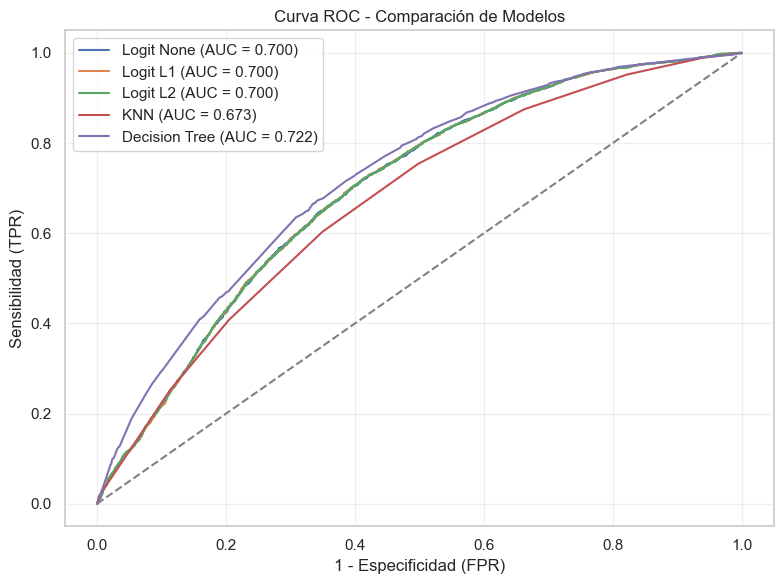

In [17]:

# =============================
# 1. Calcular FPR y TPR
# =============================
fpr_none, tpr_none, _ = roc_curve(y_test, ynone_prob)
fpr_l1,   tpr_l1,   _ = roc_curve(y_test, yl1_prob)
fpr_l2,   tpr_l2,   _ = roc_curve(y_test, yl2_prob)
fpr_knn,  tpr_knn,  _ = roc_curve(y_test, yknn_prob)
fpr_tree, tpr_tree, _ = roc_curve(y_test, ytree_prob)

# =============================
# 2. Calcular AUC
# =============================
auc_none = roc_auc_score(y_test, ynone_prob)
auc_l1   = roc_auc_score(y_test, yl1_prob)
auc_l2   = roc_auc_score(y_test, yl2_prob)
auc_knn  = roc_auc_score(y_test, yknn_prob)
auc_tree = roc_auc_score(y_test, ytree_prob)

# =============================
# 3. Graficar curvas ROC
# =============================
plt.figure(figsize=(8, 6))

plt.plot(fpr_none, tpr_none, label=f"Logit None (AUC = {auc_none:.3f})")
plt.plot(fpr_l1,   tpr_l1,   label=f"Logit L1 (AUC = {auc_l1:.3f})")
plt.plot(fpr_l2,   tpr_l2,   label=f"Logit L2 (AUC = {auc_l2:.3f})")
plt.plot(fpr_knn,  tpr_knn,  label=f"KNN (AUC = {auc_knn:.3f})")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC = {auc_tree:.3f})")

# Línea del azar
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("1 - Especificidad (FPR)")
plt.ylabel("Sensibilidad (TPR)")
plt.title("Curva ROC - Comparación de Modelos")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


7.	Recuerde que el Ministerio de Capital Humano está interesado en identificar a grupos vulnerables para dirigir los recursos de un programa de alimentos. ¿Cambió su respuesta con respecto a cuál es el “mejor” modelo para asignar recursos escasos a los más necesitados? 